# Machine Learning Project

## ETL - Lila

In [1]:
# import necessary libraries
import pandas as pd
import glob
from datetime import datetime

#### Extract Function

In [2]:
## creating the extract function 

def extract(cols) -> pd.DataFrame:
    """This functions combines all the csv, json, and parquet files into a dataframe

    Args:
        cols (list): A list of column names for the resulting dataframe
        
    Returns:
        data (pd.DataFrame): All data sources combined in a single dataframe
    """
    ## create an empty dataframe to hold all the data
    # The columns' names are given based on an earlier exploration of a csv file
    data = pd.DataFrame(columns= cols)
    
    
    for csvfile in glob.glob('final_project_data_sp2026_L/*.csv'):
        # load the current csv file into a temporary dataframe
        tmp_df = pd.read_csv(csvfile)
        
        # concatenate the loaded data with the data frame
        data = pd.concat([data, tmp_df], ignore_index=True)
    

    for jsonfile in glob.glob('final_project_data_sp2026_L/*.json'):
        # load the current json file into a temporary dataframe
        tmp_df = pd.read_json(jsonfile, lines=True)
        
        # concatenate the loaded data to the data frame
        data = pd.concat([data, tmp_df], ignore_index=True)

    for parquetfile in glob.glob('final_project_data_sp2026_L/*.parquet'):
        # load the current parquet file into a temporary dataframe
        tmp_df = pd.read_parquet(parquetfile)
        
        # concatenate the loaded data to the data frame
        data = pd.concat([data, tmp_df], ignore_index=True)

    # return the combined (extracted) data
    return data

#### Transform Function

In [3]:
def transform(data: pd.DataFrame) -> pd.DataFrame:
    """This function performs the transformations:
    1. Fix column names and remove leading spaces 
    2. Converts all columns (except `Label`) to float type
    3. Removing duplicates from the extracted data
    4. Handling missing data
    5. Remove rows with attack type Heartbleed
    6. creating new column for benign vs attack based on 'Label' column (all Dos become attack regardless of type)

    Args:
        data (pd.DataFrame): extracted data ready for transformations

    Returns:
        pd.DataFrame: transformed data
    """
    # Task 1: Fix column labels to remove leading spaces
    data.columns = data.columns.str.strip()

    # Task 2: Convert all columns (except `Label`) to float type
    # use the method astype() to convert the data type of the columns
    
    data = data.astype({col: 'float64' for col in data.columns if col != 'Label'})

    # Task 3: Remove duplicates
    # use the method drop_duplicated()
    data = data.drop_duplicates()
    
    # Task 4: Handle missing data
    # use the method dropna() to drop rows with missing values
    data = data.dropna()

    # Task 6: remove rows with attack type = 'heartbleed'

    data = data[data['Label']!='Heartbleed']

    # Task 6: Create new column for benign vs attack based on 'Label' column (all Dos become attack regardless of type)
    # use the method apply() to create a new column 'Attack_Type' based on the values in the 'Label' column
    # benign = 0, attack = 1
    data['Attack_Type'] = data['Label'].apply(lambda x: 1 if x != 'BENIGN' else 0)

    # return transformed data
    return data

#### Load Function

In [4]:
def loadcsv(data: pd.DataFrame) -> None:
    """This function loads the argument dataframe into a csv file

    Args:
        data (pd.DataFrame): extracted nd transformed dataframe
    """
    data.to_csv('all_ids.csv', index=False)

#### Logging Function

In [5]:
def log(message: str) -> None:
    """This function writes the message 'message' and time of occurrence into the file logfile.

    Args:
        logfile (str): log file
        message (str): message to be written into the log file
    """
    # datetime format. Remark that:
    ## .%f appends the parts of the second
    ## the tailing ', ' are intentionally used to separate the timestamp and the logged message
    datatime_format = '%Y-%m-%d-%H:%M:%S.%f, '
    datetimestamp = datetime.now().strftime(datatime_format)
    
    ## log events are separated by the new character
    with open('ETL.log', 'a') as file:
        file.write(datetimestamp + message + '\n')

### Running the ETL Pipeline

In [6]:
## Load in one file to get the column names:

df = pd.read_csv('final_project_data_sp2026_L/ids_0.csv')

# get column names as a list to be used in the extract function
columns = df.columns.tolist()

# checking data types and the first few rows of the data frame
print(df.dtypes)
df.head()

# get the number of nan values in the data frame
nan_counts = df.isna().sum()
print(nan_counts)

 Destination Port                int64
 Flow Duration                   int64
 Total Fwd Packets               int64
 Total Backward Packets          int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
 Idle Std                      float64
 Idle Max                        int64
 Idle Min                        int64
 Label                          object
Length: 79, dtype: object
 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64


In [7]:
log("ETL Pipeline Started")

log("Extract Phase Started")
data = extract(columns)
log("Extract Phase Ended")

log("Transform Phase Started")
data = transform(data)
log("Transform Phase Ended")

log("Load Phase (csv) Started")
loadcsv(data)
log("Load Phase (csv) Ended")

/tmp/ipykernel_16107/1911183125.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, tmp_df], ignore_index=True)


### End of ETL 

# EDA - Megan

In [8]:
# reading in the csv to pandas dataframe
data = pd.read_csv('all_ids.csv')

### Identifying the shape of the dataset

In [9]:
print(f'data shape: {data.shape}')
print(f'dataset size: {data.shape[0]}\nnumber of features: {data.shape[1]}')

data shape: (49490, 80)
dataset size: 49490
number of features: 80


### Unify the columns/feature names

In [10]:
# first - checking if there are repeat feature names
print(len(df.columns))
print(len(set(df.columns)))

# checking the naming conventions
print(data.columns)

# since some columns use spaces and some use underscores, I am going to unify the names so that everything uses underscores
data.columns = data.columns.str.strip()
data.columns = data.columns.str.replace(' ', '_')
print(data.columns)

79
79
Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN F

### Identifying Unique Values in the Class Label Variable

In [11]:
# original response column
print("Unique Values in the Class Label:",str(data['Label'].unique()))
# new response column (transformed to be binary)
print('Unique Values in Attack Type', str(data['Attack_Type'].unique()))

Unique Values in the Class Label: ['BENIGN' 'DoS Hulk' 'DoS GoldenEye' 'DoS Slowhttptest']
Unique Values in Attack Type [0 1]


### Identifying if the Dataset has Missing Data

In [12]:
print(data.isna().sum())
print(f'Total number of missing values: {data.isna().sum().sum()}')

Destination_Port               0
Flow_Duration                  0
Total_Fwd_Packets              0
Total_Backward_Packets         0
Total_Length_of_Fwd_Packets    0
                              ..
Idle_Std                       0
Idle_Max                       0
Idle_Min                       0
Label                          0
Attack_Type                    0
Length: 80, dtype: int64
Total number of missing values: 0


This dataset does not have missing data.

### Identifying columns with a high percentage of missing data
There are no columns with a high percentage of missing data, as there is no missing data in this dataset.

### Performing Univariate Analysis

In [13]:
# things I need to import later
import matplotlib.pyplot as plt
import numpy as np

# Finding the statistics of columns
column_stats = data.describe()
column_stats

# examining the variances
variances = data.var(numeric_only=True)
variances.sort_values().head(30) # there is a big jump in variance from less than 1 to 35. 
variances.describe()

# dropping columns with variances less than one
to_drop = variances[variances < 1].index
to_drop = to_drop[to_drop != "Attack_Type"] # making sure the response value is maintained
data = data.drop(columns=to_drop)

# issues with infinite data type. replacing them with nas then dropping nas
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

# visualizing - plotting each column seperately for clarity

# for col in data.columns:
#     if data[col].dtype in ['int64', 'float64']:
#         plt.figure()
#         plt.boxplot(data[col])
#         plt.title(f'Distribution of {col}')
#         plt.show()





    


### Performing bivariate analysis

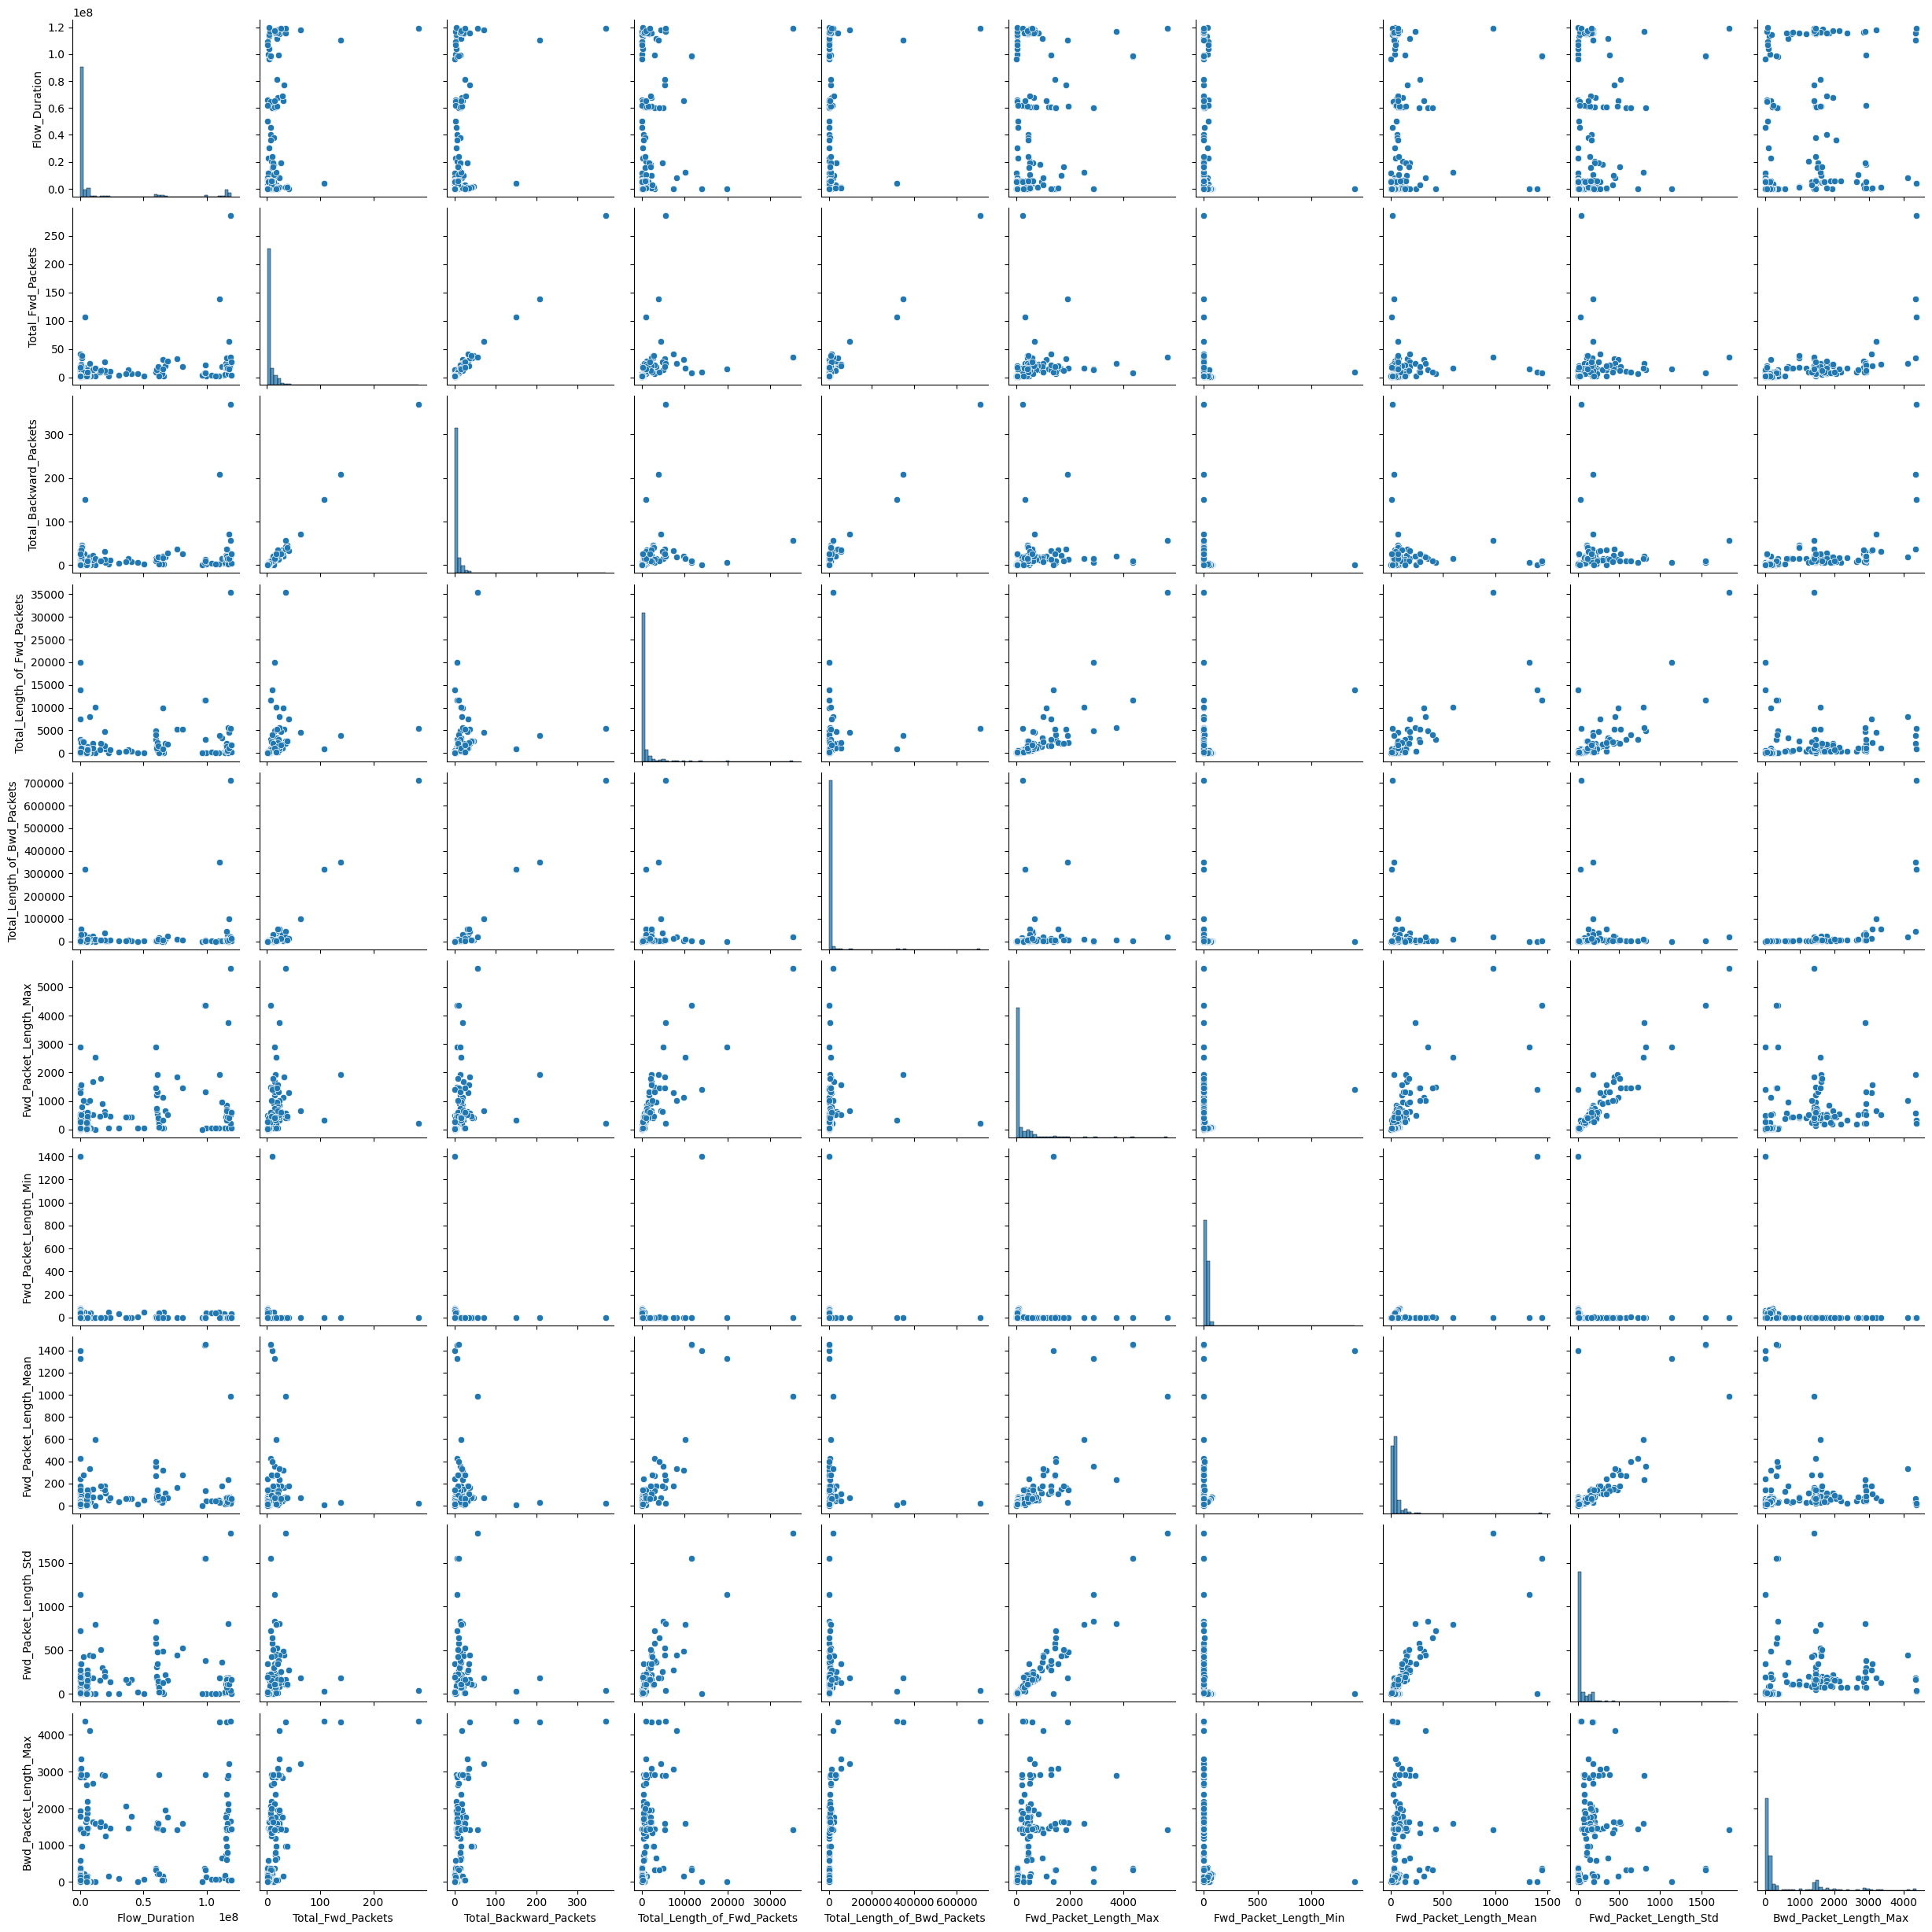

In [14]:
# doing pair plots for a subset of rows
import seaborn as sns
# doing pairplots for the first 10 columns
data_subset = data.iloc[1:501,1:11]
sns.pairplot(data_subset)

In [15]:
# correlation matrix
#data['Attack_Type']
corr_data = data.drop(columns = ["Attack_Type","Label"])
corr_data.corr().style.background_gradient(cmap='coolwarm')

,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,Bwd_Packet_Length_Max,Bwd_Packet_Length_Min,Bwd_Packet_Length_Mean,Bwd_Packet_Length_Std,Flow_Bytes/s,Flow_Packets/s,Flow_IAT_Mean,Flow_IAT_Std,Flow_IAT_Max,Flow_IAT_Min,Fwd_IAT_Total,Fwd_IAT_Mean,Fwd_IAT_Std,Fwd_IAT_Max,Fwd_IAT_Min,Bwd_IAT_Total,Bwd_IAT_Mean,Bwd_IAT_Std,Bwd_IAT_Max,Bwd_IAT_Min,Fwd_Header_Length,Bwd_Header_Length,Fwd_Packets/s,Bwd_Packets/s,Min_Packet_Length,Max_Packet_Length,Packet_Length_Mean,Packet_Length_Std,Packet_Length_Variance,Average_Packet_Size,Avg_Fwd_Segment_Size,Avg_Bwd_Segment_Size,Fwd_Header_Length.1,Subflow_Fwd_Packets,Subflow_Fwd_Bytes,Subflow_Bwd_Packets,Subflow_Bwd_Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
Destination_Port,1.000000,-0.146936,-0.005290,-0.003624,0.028145,-0.003532,0.037317,0.002545,0.080919,0.039792,-0.167369,-0.015852,-0.180140,-0.162334,0.094043,0.347788,-0.071375,-0.114537,-0.132873,-0.031700,-0.139200,-0.087602,-0.111525,-0.131760,-0.036102,-0.054283,-0.046724,-0.046631,-0.048626,-0.010514,-0.008621,-0.005700,0.335144,0.166134,-0.005292,-0.155280,-0.165109,-0.161038,-0.121637,-0.163601,0.080919,-0.180140,-0.008621,-0.005290,0.028145,-0.003624,-0.003532,-0.084864,0.170066,-0.001628,-0.072781,-0.041254,-0.011351,-0.041279,-0.039642,-0.125954,-0.027439,-0.130057,-0.121372
Flow_Duration,-0.146936,1.000000,0.019571,0.018120,0.050829,0.016610,0.143736,-0.113088,0.026758,0.163381,0.208045,-0.196265,0.242342,0.138117,-0.032738,-0.109392,0.379131,0.856158,0.964134,0.101401,0.999004,0.553722,0.860587,0.964380,0.165817,0.416417,0.342534,0.407049,0.424222,0.070186,0.023669,0.022540,-0.103902,-0.059758,-0.154539,0.216331,0.273429,0.207195,0.117104,0.260998,0.026758,0.242342,0.023669,0.019571,0.050829,0.018120,0.016614,-0.459134,-0.062480,0.015331,-0.247828,0.077607,0.084562,0.092121,0.060811,0.939709,0.178410,0.963765,0.909946
Total_Fwd_Packets,-0.005290,0.019571,1.000000,0.999252,0.506530,0.998954,0.021470,-0.004607,-0.000589,0.003706,0.024866,-0.006428,0.021082,0.005648,-0.000763,-0.003527,-0.012174,-0.004792,-0.003902,-0.009710,0.018920,-0.012879,-0.002662,-0.003889,-0.011091,0.027881,-0.002359,-0.003613,-0.000774,0.002136,0.999120,0.998552,-0.003276,-0.002292,-0.006206,0.025074,0.026273,0.011234,0.004918,0.023395,-0.000589,0.021082,0.999120,1.000000,0.506530,0.999252,0.998946,0.005249,0.002248,0.998758,-0.012162,0.005940,0.010295,0.008548,0.003999,-0.004467,0.001722,-0.004174,-0.004632
Total_Backward_Packets,-0.003624,0.018120,0.999252,1.000000,0.506428,0.998759,0.021130,-0.003025,-0.000555,0.004240,0.024345,-0.003202,0.020913,0.004332,-0.000478,-0.003190,-0.010991,-0.003681,-0.002766,-0.008334,0.017672,-0.009868,-0.000737,-0.002759,-0.008958,0.031585,-0.001722,0.000183,0.003573,-0.001735,0.997940,0.999571,-0.003127,-0.001258,-0.004394,0.024482,0.029634,0.011655,0.004418,0.027050,-0.000555,0.020913,0.997940,0.999252,0.506428,1.000000,0.998757,-0.001134,0.000505,0.998627,-0.019495,-0.005194,0.003022,-0.003368,-0.005698,-0.002370,-0.004156,-0.003043,-0.001870
Total_Length_of_Fwd_Packets,0.028145,0.050829,0.506530,0.506428,1.000000,0.494400,0.371883,0.020896,0.351575,0.336011,0.037683,-0.027014,0.032632,0.020919,0.008190,-0.014907,-0.048831,0.001198,-0.002589,-0.046969,0.047671,-0.041228,0.002593,-0.002737,-0.040018,0.107284,0.068342,0.034457,0.046394,0.087897,0.509252,0.508488,-0.014544,-0.006235,-0.003156,0.057761,0.079627,0.045622,0.017254,0.075318,0.351575,0.032632,0.509252,0.506530,1.000000,0.506428,0.494424,0.070786,0.128332,0.505016,-0.025012,0.033772,0.230874,0.090114,-0.015737,-0.006879,0.008348,-0.003423,-0.007635
Total_Length_of_Bwd_Packets,-0.003532,0.016610,0.998954,0.998759,0.494400,1.000000,0.015573,-0.002873,-0.003582,0.00033

### Performing Multivariate Analysis

In [16]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# don't need to make blobs since we already have data
Xb = data_subset
print(Xb.shape)
yb = data['Attack_Type'][1:501]
print(yb.shape)

(500, 10)
(500,)


In [18]:
Xb

,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,Bwd_Packet_Length_Max
1,113594958.0,4.0,4.0,152.0,362.0,45.0,31.0,38.000000,8.082904,120.0
2,30485.0,1.0,1.0,81.0,209.0,81.0,81.0,81.000000,0.000000,209.0
3,30445.0,1.0,1.0,53.0,81.0,53.0,53.0,53.000000,0.000000,81.0
4,70860.0,1.0,1.0,56.0,72.0,56.0,56.0,56.000000,0.000000,72.0
5,99737370.0,3.0,3.0,124.0,310.0,44.0,38.0,41.333333,3.055050,129.0
...,...,...,...,...,...,...,...,...,...,...
496,116217007.0,16.0,14.0,519.0,802.0,435.0,0.0,32.437500,107.360433,796.0
497,117680023.0,15.0,15.0,1038.0,5115.0,406.0,0.0,69.200000,112.127606,1418.0
498,119229272.0,27.0,25.0,1821.0,10863.0,595.0,0.0,67.444444,160.289242,1448.0
499,74.0,2.0,1.0,31.0,6.0,31.0,0.0,15.500000,21.920310,6.0


In [19]:
# how many label classes there are
label_classes = len(set(data['Label']))
label_classes

4

Index(['Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max',
       'Bwd_IAT_Min', 'Fwd_Header_Length', 'Bwd_Header_Length',
       'Fwd_Packets/s', 'Bwd_Packets/s', 'Min_Packet_Length',
       'Max_Packet_Length'],
      dtype='object')


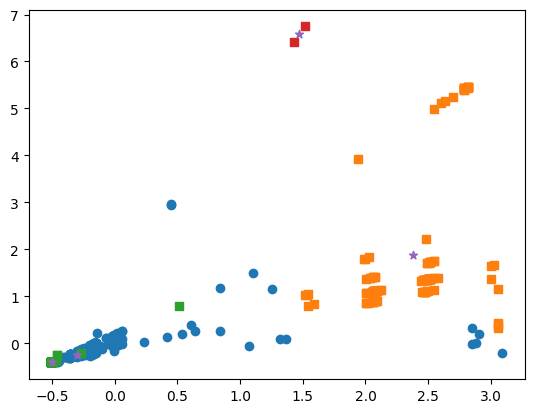

In [20]:
# doing k-means clustering with a subset of columns - 4 clusters (for the 4 label types)

# printing out the columns we are using in the subset
print(data.columns[25:36])

# randomly choosing rows for the subset - can't slice since there are many rows with the same
# response ordered together 
data_sample = data.sample(n=1000, random_state = 9182)

# standardizing
X1 = data_sample.iloc[:,25:36] 
X1 = X1.values # numpy indexing instead 
X1 = X1 - X1.mean(axis=0) 
X1 = X1/X1.std(axis=0) 

# clustering 
kmeans = KMeans(n_clusters=label_classes, init='k-means++', n_init=10) 
kmeans_pred = kmeans.fit_predict(X1) 
# visualizing 
plt.scatter(X1[kmeans_pred==0, 0], X1[kmeans_pred==0, 1], marker='o') 
plt.scatter(X1[kmeans_pred==1, 0], X1[kmeans_pred==1, 1], marker='s')
plt.scatter(X1[kmeans_pred==2, 0], X1[kmeans_pred==2, 1], marker='s')
plt.scatter(X1[kmeans_pred==3, 0], X1[kmeans_pred==3, 1], marker='s')
centroids = kmeans.cluster_centers_ 
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*')

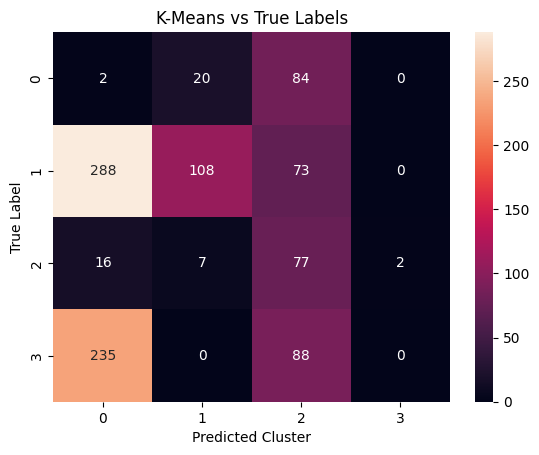

In [21]:
from sklearn.metrics import confusion_matrix

# true label subset - encoding them to be numerical
ys = pd.factorize(data_sample['Label'])[0]

# making the confusion matrix
cm = confusion_matrix(ys, kmeans_pred)

# plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted Cluster')
plt.ylabel('True Label')
plt.title('K-Means vs True Labels')
plt.show()

8. Data Preprocessing - Hillary 

In [38]:
# Required Libraries for Preprocessing 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [39]:
# Drop label column since we are doing unsupervised learning 
# Attack_Type is the new y or respose variable, but since we are doing unsupervised learning, we will not be using it for training the model. We will use it for evaluation purposes only.

processed_data = data.drop(columns = ['Label'])
processed_data.head()

,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Attack_Type
0,55109.0,17.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.000000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,53.0,113594958.0,4.0,4.0,152.0,362.0,45.0,31.0,38.0,8.082904,...,32.0,240.0,0.0,240.0,240.0,114000000.0,0.0,114000000.0,114000000.0,0
2,53.0,30485.0,1.0,1.0,81.0,209.0,81.0,81.0,81.0,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,53.0,30445.0,1.0,1.0,53.0,81.0,53.0,53.0,53.0,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,53.0,70860.0,1.0,1.0,56.0,72.0,56.0,56.0,56.0,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [40]:
# Splitting the data into training and testing sets 

# X is the main dataframe without the response variable Attack_Type 
# y is the response variable Attack_Type 
X = processed_data.drop(columns = ['Attack_Type'])
y = processed_data['Attack_Type']

# I folllowed the same parameters that we did in class for choosing test and train sizes 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=9182)

In [41]:
# Standardize and normalization of the data 
scaler = StandardScaler()

# Only using X training and X test for scaling to build the model to avoid data leakage. 
# Y is not used for scaling since it is the response variable and we are doing unsupervised learning. 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print lines of x test and x train to check if they are scaled 
print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled shape:', X_test_scaled.shape)


X_train_scaled shape: (37115, 59)
X_test_scaled shape: (12372, 59)


9. Feature Engineering - Hillary  

In [42]:
# Required Libraries for Feature Engineering 
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import r2_score, mean_squared_error

In [43]:
# L1 Lasso-based feature selection 
lasso_regression = Lasso(alpha=0.01)

# Train the laso regression model on the training dataset 
lasso_regression.fit(X_train_scaled, y_train)

# Model-based feature selection using Lasso regression
model = SelectFromModel(lasso_regression, prefit=True)

In [44]:
# Perform feature selection on the training and testing data
X_train_selected = model.transform(X_train_scaled)
X_test_selected = model.transform(X_test_scaled)

# Printing the shapes of the selected features for training and testing data 
print('X_train_selected shape:', X_train_selected.shape)
print('X_test_selected shape:', X_test_selected.shape)


X_train_selected shape: (37115, 14)
X_test_selected shape: (12372, 14)


In [45]:
# Printing the selected features 
selected_features = X.columns[model.get_support()]
print('Selected Features:', selected_features)

Selected Features: Index(['Destination_Port', 'Total_Length_of_Fwd_Packets',
       'Fwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 'Flow_IAT_Mean',
       'Flow_IAT_Max', 'Bwd_IAT_Std', 'Min_Packet_Length', 'Packet_Length_Std',
       'Average_Packet_Size', 'Subflow_Fwd_Bytes', 'Init_Win_bytes_backward',
       'min_seg_size_forward', 'Active_Mean'],
      dtype='object')


In [46]:
# Printing the model coefficients for the selected features
selected_coefficients = lasso_regression.coef_[model.get_support()]
print('Selected Coefficients:', selected_coefficients)

Selected Coefficients: [-0.0916873  -0.00334392 -0.01853259 -0.1190912   0.02403194  0.02966585
  0.0122711  -0.00392888  0.03530039  0.04431874 -0.0006026  -0.00915529
  0.0486945   0.00991793]


In [47]:
# Performing model fitting and evaluation using the selected features. 
lasso_regression.fit(X_train_selected, y_train)
y_pred = lasso_regression.predict(X_test_selected)


In [48]:
# Computing the r2-score and MSE values for the model with selected features
r2_score = r2_score(y_test, y_pred)
print('R2 Score:', r2_score)

mean_squared_error = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', mean_squared_error)


R2 Score: 0.5945823698611988
Mean Squared Error: 0.03755275668650474


10. Processed Data Loading - Hillary 

In [49]:
# Write processed data to new csv file
processed_data.to_csv('processed_data.csv', index=False)

# Convert the numpy arrays back to dataframes for writing to csv files
X_train_selected = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_selected = pd.DataFrame(X_test_selected, columns=selected_features)

# Write test and train data to new csv files 
X_train_selected.to_csv('X_train.csv', index=False)
X_test_selected.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)


11/12. Model Selection and Training & Model Evaluation - Matt
- Preceptron
- Logistic Regression Classifier
- Adaboost
- XGBoost
- LightGBM

In [53]:
#get modules 
#%pip install xgboost catboost lightgbm

In [56]:
#Importing anything I might need:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import Perceptron
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgbm
from sklearn.ensemble import VotingClassifier

A. Preceptron Training & Evaluation

In [58]:
#Creating the perceptron classifier, using the default number of iterations of 1000 and learning rate of 0.001 based on class module.
perceptron = Perceptron(eta0=0.001, random_state=1)

In [60]:
#Training the model using the above training dataset created by Hillary
perceptron.fit(X_train_selected, y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.001
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",1


In [61]:
#Predict the labels for the test dataset
pred_perc = perceptron.predict(X_test_selected)

In [62]:
#Evaluation of the perceptron model performance. 
acc_perc = accuracy_score(y_test, pred_perc)
f1score_perc = f1_score(y_test, pred_perc)
precision_perc = precision_score(y_test, pred_perc)
recall_perc = recall_score(y_test, pred_perc)

print('Perceptron Model Evaluation')
print('Accuracy: {:.3f}'.format(acc_perc))
print('Precision: {:.3f}'.format(precision_perc))
print('Recall: {:.3f}'.format(recall_perc))
print('F1-score: {:.3f}'.format(f1score_perc))

Perceptron Model Evaluation
Accuracy: 0.982
Precision: 0.981
Recall: 0.999
F1-score: 0.990


/home/matt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


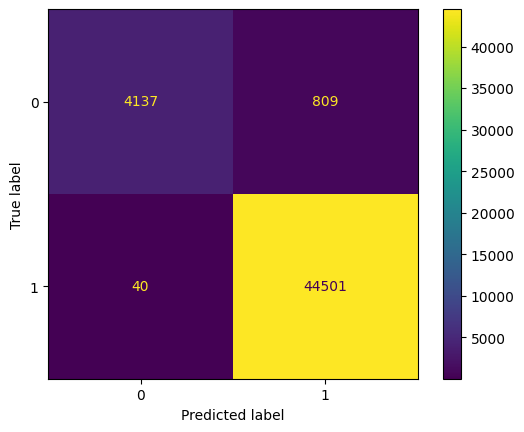

In [63]:
#Displaying the confusion matrix for the perceptron model
ConfusionMatrixDisplay.from_estimator(perceptron, np.concatenate((X_train_selected, X_test_selected), axis=0), np.concatenate((y_train, y_test)))

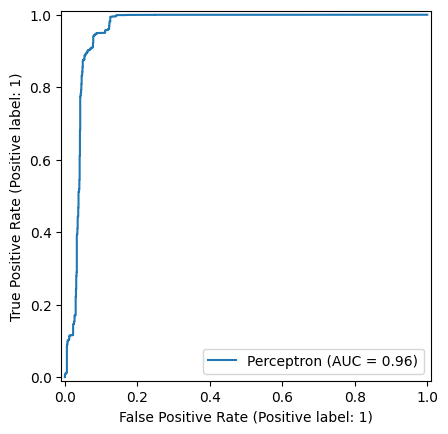

In [64]:
#Displaying the AUC 
RocCurveDisplay.from_estimator(perceptron, X_test_selected, y_test)

B. Logistic Regression Training & Evaluation

In [65]:
#Creating the logistic regression classifier.
lr = LogisticRegression(random_state=1)

In [66]:
#Training the logistic regression model using the above training dataset created by Hillary
lr.fit(X_train_selected, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [67]:
#Predicting the labels for the test set
pred_lr = lr.predict(X_test_selected)

In [68]:
#Evaluation of performance of the logistic regression model
acc_lr = accuracy_score(y_test, pred_lr)
f1score_lr = f1_score(y_test, pred_lr)
precision_lr = precision_score(y_test, pred_lr)
recall_lr = recall_score(y_test, pred_lr)

print('Logistic Regression Model Evaluation')
print('Accuracy: {:.3f}'.format(acc_lr))
print('Precision: {:.3f}'.format(precision_lr))
print('Recall: {:.3f}'.format(recall_lr))
print('F1-score: {:.3f}'.format(f1score_lr))

Logistic Regression Model Evaluation
Accuracy: 0.977
Precision: 0.976
Recall: 0.999
F1-score: 0.987


/home/matt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


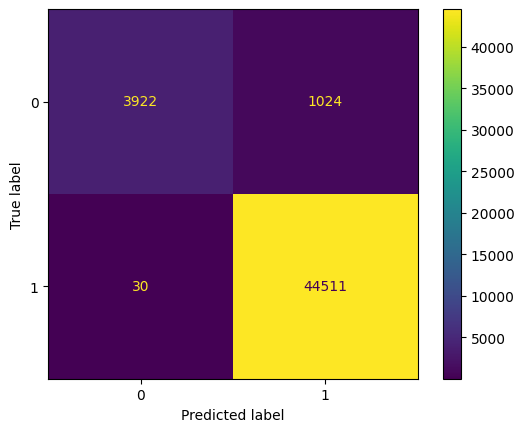

In [69]:
#Display the confusion matrix for the logistic regression model
ConfusionMatrixDisplay.from_estimator(lr, np.concatenate((X_train_selected, X_test_selected), axis=0), np.concatenate((y_train, y_test)))

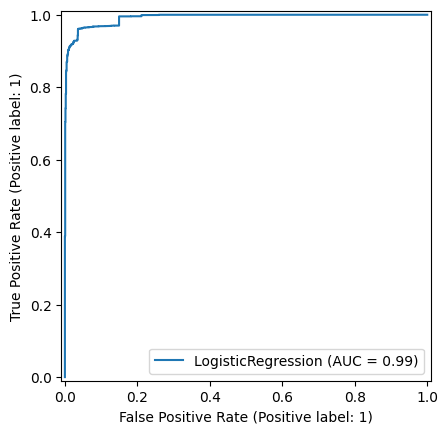

In [70]:
#Display the AUC for the logistic regression model
RocCurveDisplay.from_estimator(lr, X_test_selected, y_test)

C. Adaptive Boosting Training & Evaluation

In [72]:
#Creating an Adaboost classifier with the perceptron as the base classifer. 
adaboost_perc = AdaBoostClassifier(estimator=Perceptron(eta0=0.001, random_state=1), n_estimators=100, learning_rate=0.001, random_state=1)

In [74]:
#Training the adaboost model using the above training dataset created by Hillary
adaboost_perc.fit(X_train_selected, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",Perceptron(et...andom_state=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.001
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",1
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True


In [75]:
#Predict the labels for the test dataset
pred_ada = adaboost_perc.predict(X_test_selected)

In [76]:
#Evaluation of adaboost model performance
acc_ada = accuracy_score(y_test, pred_ada)
f1score_ada = f1_score(y_test, pred_ada)
precision_ada = precision_score(y_test, pred_ada)
recall_ada = recall_score(y_test, pred_ada)

print('Adaboost Model Evaluation')
print('Accuracy: {:.3f}'.format(acc_ada))
print('Precision: {:.3f}'.format(precision_ada))
print('Recall: {:.3f}'.format(recall_ada))
print('F1-score: {:.3f}'.format(f1score_ada))

Adaboost Model Evaluation
Accuracy: 0.981
Precision: 0.983
Recall: 0.995
F1-score: 0.989


/home/matt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


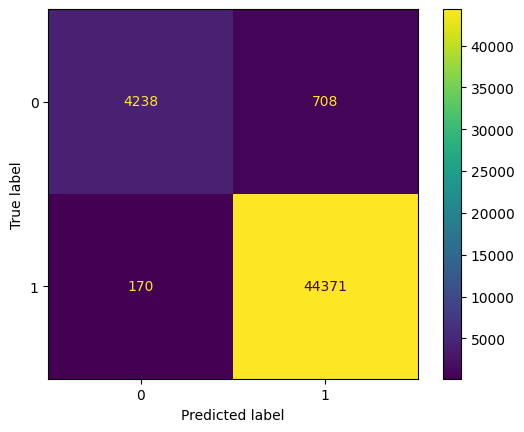

In [77]:
#Display the confusion matrix for adaboost model
ConfusionMatrixDisplay.from_estimator(adaboost_perc, np.concatenate((X_train_selected, X_test_selected), axis=0), np.concatenate((y_train, y_test)))

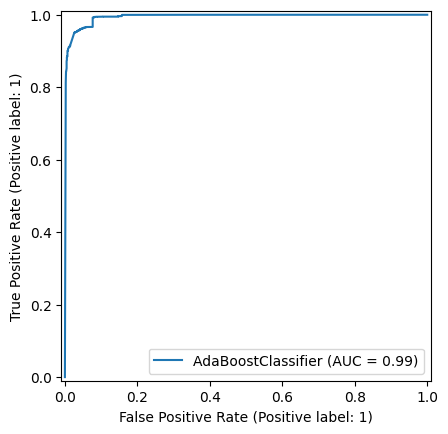

In [78]:
#Displaying the AUC for the adaboost model
RocCurveDisplay.from_estimator(adaboost_perc, X_test_selected, y_test)   

D. XGBoost Training & Evaluation

In [79]:
#Creating the xgboost classifier
xgboost_clf = XGBClassifier(random_state=1, n_estimators=100)

In [80]:
#Training the xgboost model using the above training dataset created by Hillary
xgboost_clf.fit(X_train_selected, y_train, verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [81]:
#XGBoost model predictions
pred_xgb = xgboost_clf.predict(X_test_selected)

In [82]:
#Evaluation of XGBoost model performance
acc_xgb = accuracy_score(y_test, pred_xgb)
f1score_xgb = f1_score(y_test, pred_xgb)
precision_xgb = precision_score(y_test, pred_xgb)
recall_xgb = recall_score(y_test, pred_xgb)

print('XGBoost Model Evaluation')
print('Accuracy: {:.3f}'.format(acc_xgb))
print('Precision: {:.3f}'.format(precision_xgb))
print('Recall: {:.3f}'.format(recall_xgb))
print('F1-score: {:.3f}'.format(f1score_xgb))

XGBoost Model Evaluation
Accuracy: 0.999
Precision: 1.000
Recall: 1.000
F1-score: 1.000


In [ ]:
#Curious what the features of importance were for xgboost model
xgboost_clf.feature_importances_ 

array([1.9682805e-01, 2.1202937e-03, 4.9034040e-03, 9.2254961e-03,
       1.5177942e-03, 1.1174477e-03, 2.0312080e-03, 7.2322482e-01,
       8.8820308e-03, 2.3816995e-02, 0.0000000e+00, 2.0783152e-02,
       5.4210564e-03, 1.2833151e-04], dtype=float32)

In [ ]:
#What are those feature names?
xgboost_clf.feature_names_in_

#Looks like Min_Packet_Length has the most importance for the xgboost model, followed by Destination_Port. The two account for about 92% of the importance for the xgboost model.

array(['Destination_Port', 'Total_Length_of_Fwd_Packets',
       'Fwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 'Flow_IAT_Mean',
       'Flow_IAT_Max', 'Bwd_IAT_Std', 'Min_Packet_Length',
       'Packet_Length_Std', 'Average_Packet_Size', 'Subflow_Fwd_Bytes',
       'Init_Win_bytes_backward', 'min_seg_size_forward', 'Active_Mean'],
      dtype='<U27')

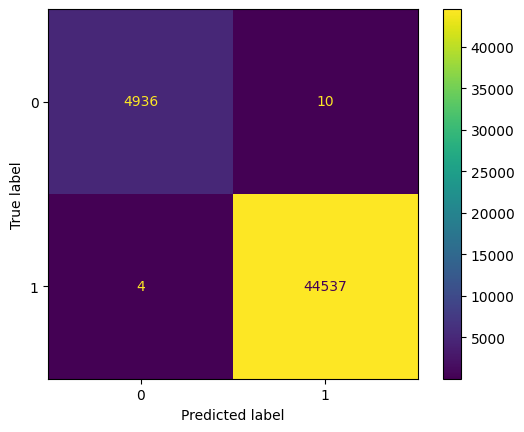

In [88]:
#Display the confusion matrix for the xgboost model
ConfusionMatrixDisplay.from_estimator(xgboost_clf, np.concatenate((X_train_selected, X_test_selected), axis=0), np.concatenate((y_train, y_test)))

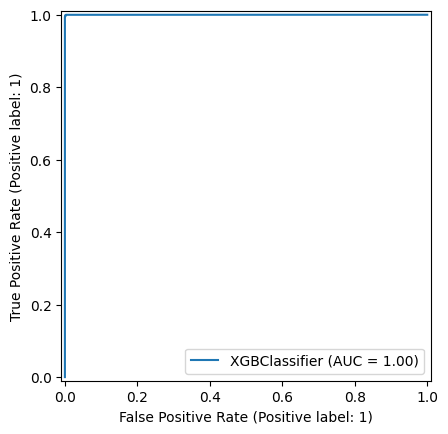

In [89]:
#Display the AUC for the xgboost model
RocCurveDisplay.from_estimator(xgboost_clf, X_test_selected, y_test)

E. LightGBM Training & Evaluation

In [90]:
#Creating the lightGBM classifier
lgbm_clf = lgbm.LGBMClassifier(random_state=1, n_estimators=100)

In [91]:
#Training the lightGBM model using the above training dataset created by Hillary
lgbm_clf.fit(X_train_selected, y_train)

[LightGBM] [Info] Number of positive: 33447, number of negative: 3668
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002834 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3037
[LightGBM] [Info] Number of data points in the train set: 37115, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.901172 -> initscore=2.210316
[LightGBM] [Info] Start training from score 2.210316


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [92]:
#Testing the lightGBM model using the above test dataset created by Hillary
pred_lgbm = lgbm_clf.predict(X_test_selected)

In [93]:
#Evaluation of the lightGBM model performance
acc_lgbm = accuracy_score(y_test, pred_lgbm)
f1score_lgbm = f1_score(y_test, pred_lgbm)
precision_lgbm = precision_score(y_test, pred_lgbm)
recall_lgbm = recall_score(y_test, pred_lgbm)

print('LightGBM Model Evaluation')
print('Accuracy: {:.3f}'.format(acc_lgbm))
print('Precision: {:.3f}'.format(precision_lgbm))
print('Recall: {:.3f}'.format(recall_lgbm))
print('F1-score: {:.3f}'.format(f1score_lgbm))

LightGBM Model Evaluation
Accuracy: 0.999
Precision: 0.999
Recall: 1.000
F1-score: 1.000


In [101]:
#What are the features of importance for the lightGBM model?
lgbm_clf.feature_importances_ / sum(lgbm_clf.feature_importances_)

array([0.10033333, 0.049     , 0.031     , 0.02933333, 0.23666667,
       0.15166667, 0.034     , 0.01633333, 0.06733333, 0.06533333,
       0.        , 0.15933333, 0.03833333, 0.02133333])

In [ ]:
#What are those feature names to correspond to importance values?
lgbm_clf.feature_name_

#Looks like Flow_IAT_Mean has the most importance for the lightGBM model, followed by Init_Win_bytes_backward, Flow_IAT_Max, and Destination Port. Together, they account for about 65% of the importance for the lightGBM model, if the indexing of feature names is the same as the order of importance values.

['Destination_Port',
 'Total_Length_of_Fwd_Packets',
 'Fwd_Packet_Length_Max',
 'Bwd_Packet_Length_Min',
 'Flow_IAT_Mean',
 'Flow_IAT_Max',
 'Bwd_IAT_Std',
 'Min_Packet_Length',
 'Packet_Length_Std',
 'Average_Packet_Size',
 'Subflow_Fwd_Bytes',
 'Init_Win_bytes_backward',
 'min_seg_size_forward',
 'Active_Mean']

/home/matt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


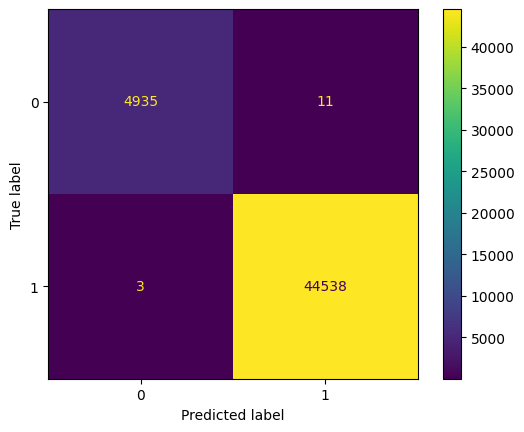

In [102]:
#Display the confusion matrix for the lightGBM model
ConfusionMatrixDisplay.from_estimator(lgbm_clf, np.concatenate((X_train_selected, X_test_selected), axis=0), np.concatenate((y_train, y_test)))

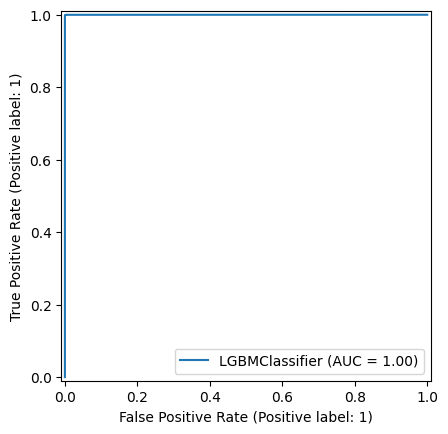

In [103]:
#Display the AUC for the lightGBM model
RocCurveDisplay.from_estimator(lgbm_clf, X_test_selected, y_test)    

### Summary of Model Performance

A. Perceptron Model Metrics:
- Accuracy: 0.982
- Precision: 0.981
- Recall: 0.999
- F1-score: 0.990

B. Logistic Regression Classifier Metrics:
- Accuracy: 0.977
- Precision: 0.976
- Recall: 0.999
- F1-score: 0.987

C. Adaboost Model Metrics:
- Accuracy: 0.981
- Precision: 0.983
- Recall: 0.995
- F1-score: 0.989

D. XGBoost Model Metrics:
- Accuracy: 0.999
- Precision: 1.000
- Recall: 1.000
- F1-score: 1.000

E. LightGBM Model Metrics: 
- Accuracy: 0.999
- Precision: 0.999
- Recall: 1.000
- F1-score: 1.000

Given the above performance metrics between the 5 classifier models, XGBoost and LightGBM are the best performing models in predicting whether traffic was benign or a DOS attack, though all performed really well and were close behind. The two actually had the same combined number of false positives and false negatives, based on the confusion matrices and the AUC also looked identical. 

Interestingly, XGBoost considered Min_Packet_Length to have the highest importance of the model, followed by Destination_Port; whereas, LightGBM considered Flow_IAT_Mean to have the highest importance of the model, followed by Init_Win_bytes_backward, Flow_IAT_Max, and Destination Port. 